# The Quiet-Period-Expiry Pop — a quantitative teardown 🔬
### The [20..30] CAR-window *t* · a paired within-IPO placebo · a 20-seed random-window placebo · the [15..35] day-by-day anatomy · a costed timer trade · the pre/post-2021 era contrast · a 20-seed synthetic null

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Faded_since_2021%3F: Mixed](https://img.shields.io/badge/Faded_since_2021%3F-Mixed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **the stock pops when the underwriters' 25-day analyst quiet period ends** — has a real academic anchor (Bradley, Jordan & Ritter 2003) and a hard, calendar-known mechanism (FINRA Rule 2711). The job here is to run the same kind of test on a fresh sample and report exactly where it stops clearing the bar.

> ⚠️ **Data note.** 66 hardcoded, real, underwritten US IPOs 2015→2025 (direct listings and SPAC mergers excluded by construction), daily adjusted closes + SPY, yfinance, cached. 60 IPOs carry a full post-listing window. Abnormal return = stock − SPY, same calendar date (beta = 1). Survivorship on data availability only, named. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `a790bce88c75` / `4adda6645406`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from quiet_period_expiry import data, strategy as st

BASKET = data.basket_frame()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.fetch_event_panel()
else:
    PANEL = None
print("real cache present:", HAVE_REAL, "| basket:", len(BASKET),
      "| IPOs on tape:", (0 if PANEL is None else PANEL['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_basket': 66, 'n_tape': 60, 'cal_lo': '2015-01-23', 'cal_hi': '2025-06-05', 'car_mean': 3.346, 'car_median': 1.616, 'car_sd': 16.561, 'car_t': 1.56, 'hit': 33, 'hit_n': 60, 'hit_pct': 55.0, 'wilson': (42.5, 66.9), 'placebo_paired_diff': 0.858, 'placebo_paired_t': 0.29, 'placebo_rand_obs': 3.346, 'placebo_rand_mean': 2.207, 'placebo_rand_sd': 1.789, 'placebo_rand_p': 0.2606, 'placebo_rand_n': 20000, 'anatomy': {15: (-0.07, -0.12), 16: (-1.17, -2.4), 17: (0.82, 1.31), 18: (0.85, 1.37), 19: (-0.06, -0.11), 20: (-0.11, -0.17), 21: (-0.44, -0.92), 22: (-0.26, -0.51), 23: (0.86, 1.99), 24: (-0.99, -1.76), 25: (1.5, 1.75), 26: (1.28, 1.88), 27: (0.15, 0.17), 28: (0.32, 0.74), 29: (-0.07, -0.13), 30: (1.11, 1.04), 31: (0.54, 1.04), 32: (0.6, 0.89), 33: (0.01, 0.01), 34: (-0.19, -0.29), 35: (0.09, 0.14)}, 'timer_gross': 2.16, 'timer_net5': 2.06, 'timer_net10': 1.96, 'timer_t_gross': 1.57, 'timer_t_net5': 1.5, 'timer_t_net10': 1.43, 'timer_hit': 56.7, 'timer_best': 30.26, 'timer_worst': -24.32, 'timer_n': 60, 'era_split': '2021-06-01', 'era_early': 5.023, 'era_early_n': 38, 'era_early_t': 1.72, 'era_late': 0.449, 'era_late_n': 22, 'era_late_t': 0.15, 'era_diff_t': -1.11, 'syn_null_mean': 0.05, 'syn_null_sd': 1.12, 'syn_null_fire': 1, 'syn_planted_pop': 400, 'syn_planted_car': 4.982, 'syn_planted_t': 3.31, 'fp_panel': 'a790bce88c75', 'fp_abn': '4adda6645406'}


real cache present: True | basket: 66 | IPOs on tape: 60


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | [20..30] CAR **+3.346%** (median +1.62%, sd 16.6%, n=60): one-sample **t = 1.56**, paired placebo t = 0.29, random-window placebo p = 0.26 |
| **Tradability** | `MIRAGE` | buy-22/sell-27 timer nets +2.06% at t = 1.50; best/worst +30.3% / -24.3% on n=60 |
| **Faded since 2021?** | `MIXED` | era CAR +5.02% (t=1.72, n=38) -> +0.45% (t=0.15, n=22); diff t = -1.11 |

> 💡 In plain words: a real published finding, a positive point estimate on a fresh sample, and *t*-stats that stay stubbornly under the certification bar at every cut we tried.

## 1 · The claim, steelmanned

Let $CAR_i$ be IPO $i$'s cumulative market-adjusted (beta = 1) abnormal return over trading days $[20..30]$ since its first close (day 0). FINRA Rule 2711 bars the managing underwriter(s) from publishing research on the issuer for 25 *calendar* days; the window tested here brackets the trading-day proxy for that expiry, allowing for the administrative lag between quiet-period end and the actual initiation report. The claims:

- **H₁ (pop).** $E[CAR_i] \gg 0$ — a systematic, cross-sectionally consistent abnormal return in the expiry window, not a handful of lucky names.
- **H₂ (specificity).** The [20..30] window is unusual *relative to the rest of the same IPOs' early trading life* — not just positive because post-IPO drift is generally positive.
- **H₃ (bankability).** A retail-executable timer (buy day 22, sell day 27) captures the pop net of costs.
- **H₄ (decay).** The effect has weakened as the finding became widely known and (partially) arbitraged/anticipated.

We find **H₁ not certified** (t = 1.56), **H₂ rejected** (paired placebo t = 0.29; random-window placebo p = 0.26), **H₃ not certified** (t = 1.50, fat tails), **H₄ suggestive but not certified** (era-diff t = −1.11).

## 2 · So what? — inference design

Each IPO has its own listing date, so unlike a shared-calendar event study (e.g. an FOMC decision) these 60 events are (largely) **cross-sectionally independent** — the planned primary is a **one-sample *t*** on the per-IPO CAR across IPOs, not a Welch split against a pooled control. Because "the window is positive" alone doesn't distinguish a real day-25 effect from generic post-IPO drift, we add a **paired within-IPO placebo** (the [20..30] CAR minus a same-width [3..13] CAR from the *same* ticker, differencing out any per-IPO level effect) and a **random-window placebo** — 20,000 (20 seeds × 1,000) independently-drawn same-width windows per IPO, giving a distribution-free right-tail *p*. The era split (2021-06-01, the sample's approximate calendar midpoint) is fixed *ex ante*, tested as a difference, not eyeballed.

## 3 · How we'd know — the protocol

- **Basket.** 66 hardcoded, real, underwritten US IPOs 2015-01-23 → 2025-06-05 (direct listings & SPAC mergers excluded by construction). 60 carry a full post-listing window.
- **Tape.** Daily adjusted closes + SPY, yfinance, cached. As-of 2026-06-30 (last complete month).
- **Headline.** One-sample t on the [20..30] per-IPO CAR + Wilson hit rate.
- **Specificity.** Paired [20..30] − [3..13] placebo (same ticker) + 20-seed random-window placebo.
- **Anatomy.** Mean abnormal return per trading day, [15..35], one-sample t each.
- **Execution (third axis).** Buy day 22 close, sell day 27 close; 2 × one-way cost × NAV; long-only, no borrow.
- **Control.** Synthetic per-IPO abnormal-return panel, planted-pop knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The headline window and its placebos

One-sample t on the [20..30] CAR, the paired within-IPO placebo, and the random-window null. In the notebook we run a lighter placebo (4 seeds × 200 draws) and quote the canonical 20,000-draw p from `results.md`.

[20..30] CAR: mean +3.346%  (median +1.616%, sd 16.56%, n=60)
one-sample t = +1.56   hit 33/60 = 55.0%  Wilson [42.5%, 66.9%]
paired placebo: diff +0.858%  t = +0.29


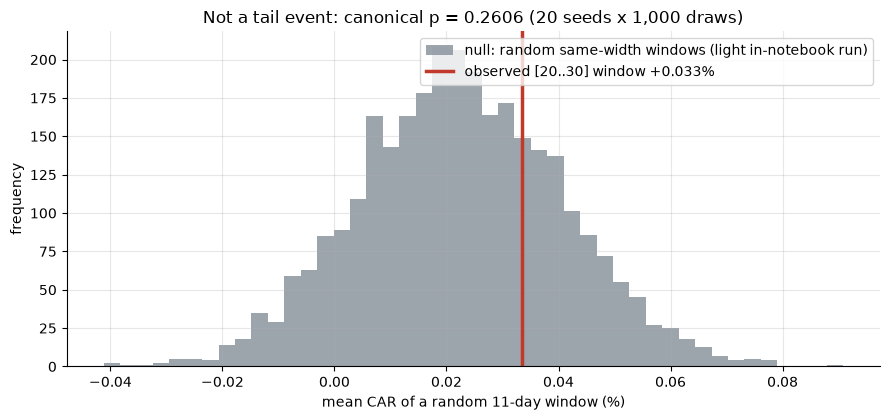

canonical placebo (results.md): mean +2.207%, sd 1.789%, p = 0.2606


In [2]:
if HAVE_REAL:
    c = st.car_window_stats(PANEL)
    print(f"[20..30] CAR: mean {c['mean_car_pct']:+.3f}%  "
          f"(median {c['median_car_pct']:+.3f}%, sd {c['std_car_pct']:.2f}%, n={c['n']})")
    print(f"one-sample t = {c['t']:+.2f}   "
          f"hit {c['hit_up']}/{c['n']} = {c['hit_rate']*100:.1f}%  "
          f"Wilson [{c['hit_lo']*100:.1f}%, {c['hit_hi']*100:.1f}%]")
    pp = st.paired_placebo_stats(PANEL)
    print(f"paired placebo: diff {pp['mean_diff_pct']:+.3f}%  t = {pp['t']:+.2f}")
    rp = st.random_window_placebo(PANEL, n_draws_per_seed=200, n_seeds=4)
    obs, draws_mean, draws_sd = rp['obs'], rp['placebo_mean'], rp['placebo_sd']
else:
    obs, draws_mean, draws_sd = R['placebo_rand_obs'], R['placebo_rand_mean'], R['placebo_rand_sd']
rng = np.random.default_rng(654)
draws = rng.normal(draws_mean, draws_sd, 3000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=45, color=GREY, alpha=.85,
        label='null: random same-width windows (light in-notebook run)')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed [20..30] window {obs:+.3f}%')
ax.set_xlabel('mean CAR of a random 11-day window (%)')
ax.set_ylabel('frequency')
ax.set_title(f"Not a tail event: canonical p = {R['placebo_rand_p']:.4f} "
             '(20 seeds x 1,000 draws)')
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical placebo (results.md): mean {R['placebo_rand_mean']:+.3f}%, "
      f"sd {R['placebo_rand_sd']:.3f}%, p = {R['placebo_rand_p']:.4f}")

> 💡 In plain words: the observed **+3.35%** sits under two placebo-sigmas from the null's center (+2.21% ± 1.79%); canonical **p = 0.26** — not remotely rare. With one-sample t = **1.56** and paired-placebo t = **0.29**, H₁ and H₂ both fail to clear the desk bar.

### 4b · Anatomy — is any single day special?

Mean abnormal return per trading day, [15..35], one-sample t vs zero at each.

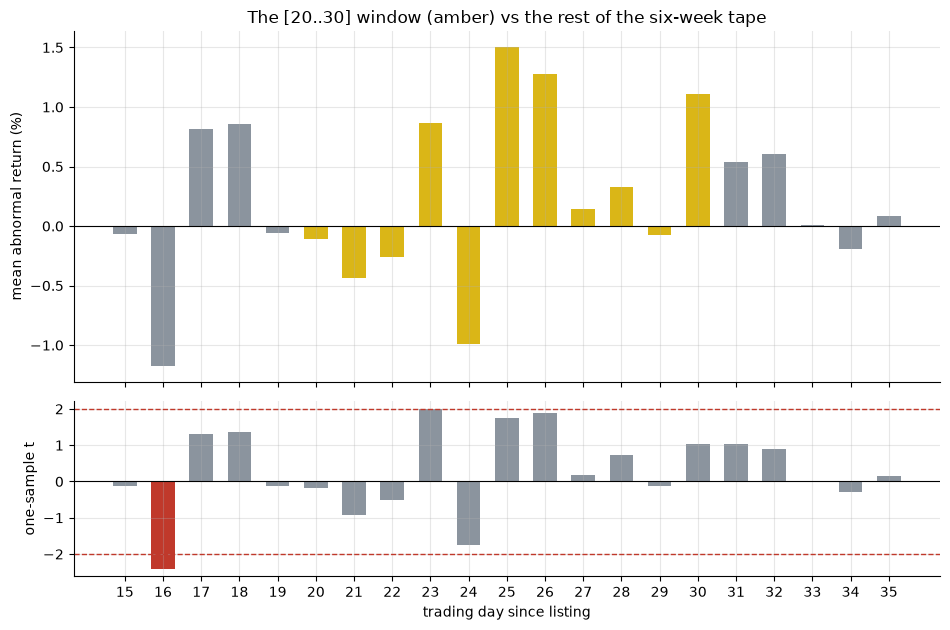

day 25: {'mean_pct': 1.5, 't': 1.75}


In [3]:
if HAVE_REAL:
    ev = st.per_day_stats(PANEL, lo=15, hi=35)
    ks = list(ev.index); ms = list(ev['mean_pct']); ts = list(ev['t_stat'])
else:
    ks = sorted(R['anatomy']); ms = [R['anatomy'][k][0] for k in ks]
    ts = [R['anatomy'][k][1] for k in ks]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.6, 6.4), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
cols = [AMBER if 20 <= k <= 30 else GREY for k in ks]
a1.bar([str(k) for k in ks], ms, color=cols, width=.62)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean abnormal return (%)')
a1.set_title('The [20..30] window (amber) vs the rest of the six-week tape')
a2.bar([str(k) for k in ks], ts, color=[RED if abs(t)>=2 else GREY for t in ts], width=.62)
a2.axhline(0, c='k', lw=.8)
a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(2, ls='--', c=RED, lw=1)
a2.set_ylabel('one-sample t'); a2.set_xlabel('trading day since listing')
plt.tight_layout(); plt.show()
print('day 25:', dict(mean_pct=R['anatomy'][25][0], t=R['anatomy'][25][1]))

> 💡 In plain words: the [20..30] window (amber) doesn't visually separate from the grey rest of the tape, and the *t*-panel shows only **one** bar past |t| = 2 in the whole [15..35] neighborhood — day 16 at **t = -2.40**, which is *negative* and weeks before the quiet period even ends. Day 25 itself: +1.50% (t = 1.75). No clean one-shot event on the day the story predicts.

### 4c · The literal trade, costed

Buy day 22's close, sell day 27's close — the version an actual account could place — gross and net of one-way costs × 2.

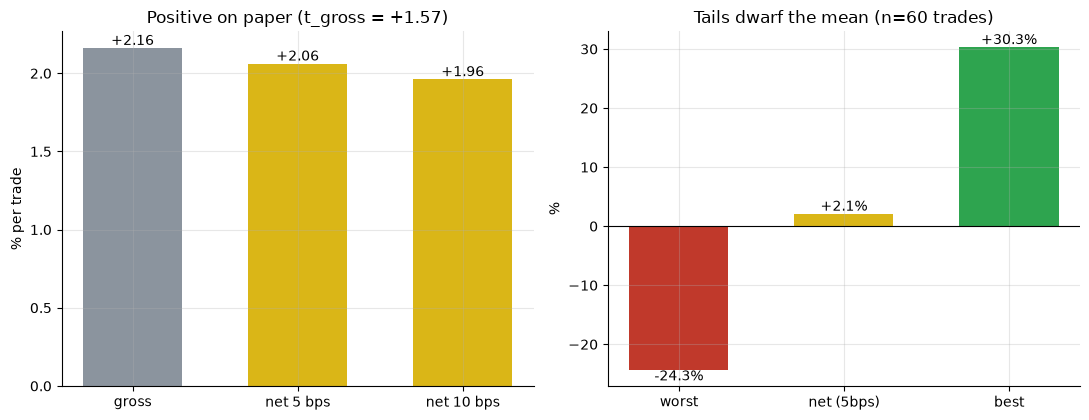

gross +2.16 -> net +2.06/+1.96%  (t_net5=+1.50);  hit 56.7%  worst -24.3%  best +30.3%


In [4]:
if HAVE_REAL:
    rows = [st.timer_strategy(PANEL, cost_bps=cb) for cb in (5.0, 10.0)]
    g = rows[0]['gross_pct']; n5, n10 = rows[0]['net_pct'], rows[1]['net_pct']
    tg, tn5 = rows[0]['t_gross'], rows[0]['t_net']
    worst, best, hit = rows[0]['worst_pct'], rows[0]['best_pct'], rows[0]['hit_rate']
else:
    g, n5, n10 = R['timer_gross'], R['timer_net5'], R['timer_net10']
    tg, tn5 = R['timer_t_gross'], R['timer_t_net5']
    worst, best, hit = R['timer_worst'], R['timer_best'], R['timer_hit']/100
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(['gross', 'net 5 bps', 'net 10 bps'], [g, n5, n10], color=[GREY, AMBER, AMBER], width=.6)
for i, v in enumerate([g, n5, n10]): a1.annotate(f'{v:+.2f}', (i, v), ha='center', va='bottom')
a1.set_ylabel('% per trade'); a1.set_title(f'Positive on paper (t_gross = {tg:+.2f})')
a2.bar(['worst', 'net (5bps)', 'best'], [worst, n5, best], color=[RED, AMBER, GREEN], width=.6)
for i, v in enumerate([worst, n5, best]): a2.annotate(f'{v:+.1f}%', (i, v), ha='center',
    va='bottom' if v >= 0 else 'top')
a2.axhline(0, c='k', lw=.8)
a2.set_ylabel('%'); a2.set_title('Tails dwarf the mean (n=60 trades)')
plt.tight_layout(); plt.show()
print(f'gross {g:+.2f} -> net {n5:+.2f}/{n10:+.2f}%  (t_net5={tn5:+.2f});  '
      f'hit {hit*100:.1f}%  worst {worst:+.1f}%  best {best:+.1f}%')

> 💡 In plain words: +2.06% net per trade sounds like free money for a five-session hold — until you see the spread: a single **-24.3%** loss or **+30.3%** gain on 60 trades outweighs the entire claimed effect. At t = 1.50 the mean itself is not certifiable. This is concentrated idiosyncratic risk in a handful of volatile small/mid-cap names, not a diversified, repeatable edge — **H₃ not certified; Tradability = MIRAGE.**

### 4d · The era contrast — has it faded?

Split at **2021-06-01** (the sample's approximate calendar midpoint, fixed before any statistics were run) and tested as a **difference**, not eyeballed.

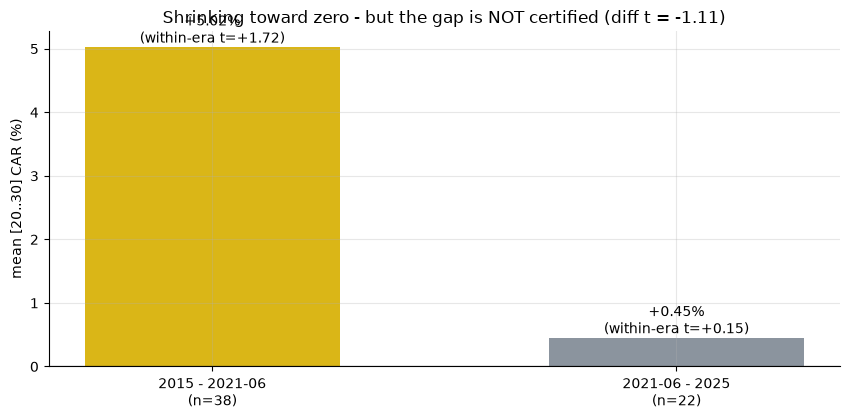

early +5.02% (t=+1.72, n=38)  late +0.45% (t=+0.15, n=22)  diff t = -1.11


In [5]:
if HAVE_REAL:
    ec = st.era_contrast(PANEL, BASKET)
    e, l = ec['early_pct'], ec['late_pct']
    et, lt, dt = ec['t_early'], ec['t_late'], ec['t_diff']
    ne, nl = ec['n_early'], ec['n_late']
else:
    e, l = R['era_early'], R['era_late']
    et, lt, dt = R['era_early_t'], R['era_late_t'], R['era_diff_t']
    ne, nl = R['era_early_n'], R['era_late_n']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar([f'2015 - 2021-06\n(n={ne})', f'2021-06 - 2025\n(n={nl})'], [e, l],
       color=[AMBER, GREY], width=.55)
for i,(v,t_) in enumerate([(e,et),(l,lt)]):
    ax.annotate(f'{v:+.2f}%\n(within-era t={t_:+.2f})',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean [20..30] CAR (%)')
ax.set_title(f'Shrinking toward zero - but the gap is NOT certified (diff t = {dt:+.2f})')
plt.tight_layout(); plt.show()
print(f'early {e:+.2f}% (t={et:+.2f}, n={ne})  late {l:+.2f}% (t={lt:+.2f}, n={nl})  diff t = {dt:+.2f}')

> 💡 In plain words: the point estimate goes from **+5.02%** (t = 1.72 — the closest this whole study gets to significance) to **+0.45%** (t = 0.15) in the second half of the sample — but the Welch t of the difference is only **-1.11**, so we may not claim decay outright. Plausible story: the effect became well-documented folklore and got partially anticipated/arbitraged; honest reading: suggestive, not proven — **H₄ MIXED.**

### 4e · Faithful-engine & power control — we know the truth here

Synthetic per-IPO abnormal-return panel, i.i.d. daily noise, TUNABLE planted pop spread across [20..30]. The null (pop = 0) is checked over **20 seeds** — never a single stream.

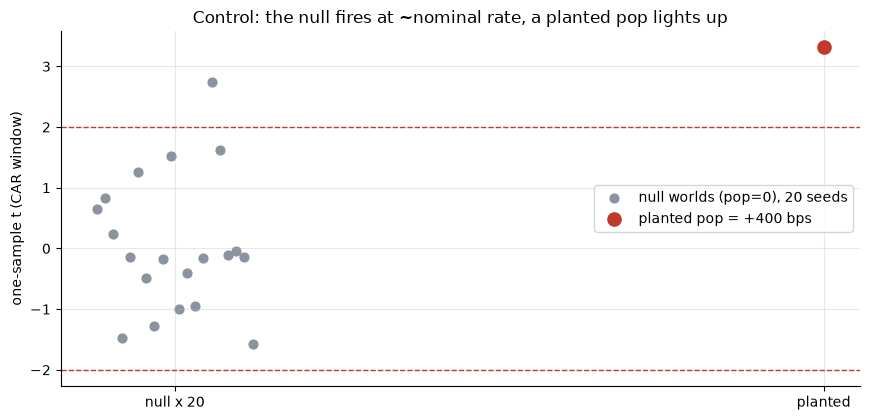

null: mean t = +0.05 (sd 1.12), |t|>=2 in 1/20 seeds  |  planted t = +3.31


In [6]:
null_ts = []
for s_ in range(20):
    p, _ = data.synthetic_panel(pop_bps=0.0, seed=654 + s_)
    null_ts.append(st.synthetic_detect(p)['t'])
null_ts = np.asarray(null_ts)
p_planted, _ = data.synthetic_panel(pop_bps=400.0, seed=654)
planted_t = st.synthetic_detect(p_planted)['t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (pop=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5,
           label='planted pop = +400 bps')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('one-sample t (CAR window)')
ax.set_title('Control: the null fires at ~nominal rate, a planted pop lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector fires (|t| ≥ 2) in **1/20** seeds — almost exactly the nominal 5% false-positive rate for a two-sided *t* ≥ 2 threshold — and a planted +400 bps pop reads t = 3.31. The machinery is unbiased and has power; the real-tape t = 1.56 is the genuine measurement, not a blind spot. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `WEAK`** — [20..30] CAR **+3.346%** (n=60): one-sample t = **1.56**, paired placebo t = **0.29**, random-window placebo p = **0.26**, no individual day in [15..35] clears t = 2 on the claim's side. BJR (2003) found it real on 1996–2000 IPOs; this 2015–2025 tape can't certify it.
- **Tradability `MIRAGE`** — the buy-22/sell-27 timer nets **+2.06%** at t = **1.50** with a **+30.3% / -24.3%** best/worst spread on 60 trades — uncertifiable and tail-dominated.
- **Faded since 2021? `MIXED`** — +5.02% (t=1.72) → +0.45% (t=0.15); the shrinkage is directionally consistent with the folklore getting arbitraged away, but the Welch t of the difference (t = -1.11) does not certify it.

## 6 · Going further

- **Fixed-calendar pooling likely dilutes a real, firm-specific event.** BJR (2003) had access to the *actual* initiation dates per IPO; those vary by a week or more around the quiet-period expiry (compliance timing, scheduling). Pooling on a fixed trading-day count instead of the true event date smears any real bump across neighboring days — the natural sequel is to hand-collect initiation dates for a subsample and re-run the event study on the true event day.
- **The mechanism (conflicted, one-sided opinions) is not in doubt** — Michaely & Womack (1999) and the 2003 Global Settlement itself document it. What's in doubt is whether *price* still reacts to a well-telegraphed, calendar-known burst of predictable opinions, two decades after the original finding and in a market where algorithmic/quant desks price calendar effects in advance.
- **Dedup map:** [219-ipo-pop](../../219-ipo-pop/) (day-1 underpricing), [319-lockup-expiry](../../319-lockup-expiry/) (the 180-day share unlock, same panel design), [623-ipo-long-run-underperformance](../../623-ipo-long-run-underperformance/) (3-5 years), [636-exchange-listing-pop](../../636-exchange-listing-pop/) (crypto listing pop/fade).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*